In [7]:
import ROOT, json, uproot
from pathlib import Path
import time
import ddfUtils.root as ddf_root
from ddfUtils.mpl_styling import add_label
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

plt.style.use("root")

ROOT.gROOT.SetBatch(True)

In [4]:
OUTPUT_ROOT = Path(
    "/eos/user/i/idioniso/sndMuTri/out/topological_distributions.root"
)
OUTPUT_ROOT.parent.mkdir(parents=True, exist_ok=True)

PGUN_ROOT = Path("/eos/user/i/idioniso/sndMuTri/out/pGun_response.root")
MC_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/trimuon_boost100/trimuon_digCPP_hough_cutset8.parquet"
)
DATA_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/run_006640/sndsw_raw_cutset8_hough.parquet"
)
GAL_PATH = Path(
    "/eos/user/i/idioniso/sndMuTri/data/cutset8/gallery/mu3_search_hough_cutset8.parquet"
)

In [3]:
with uproot.open(PGUN_ROOT) as f_meta:
    meta = json.loads(str(f_meta["metadata"]))
    w_bar_sf = meta.get("w_bar_SF", 2.18)
    qdc_bar_sf = meta.get("qdc_bar_SF", 2.58)
    w_bar_ds = meta.get("w_bar_DS", 2.12)
    qdc_bar_ds = meta.get("qdc_bar_DS", 102.34)

print(
    f"[*] Loaded MIP Baselines: SF (w={w_bar_sf:.2f}, QDC={qdc_bar_sf:.2f}) |"
    f" DS (w={w_bar_ds:.2f}, QDC={qdc_bar_ds:.2f})"
)

[*] Loaded MIP Baselines: SF (w=2.18, QDC=2.58) | DS (w=2.12, QDC=102.34)


In [4]:
TRACK_COLS = [
    "n_lines_sf_xz", "n_lines_sf_yz", "n_lines_ds_xz", "n_lines_ds_yz",
    "xz_sf_m1",
    "xz_sf_c1",
    "yz_sf_m1",
    "yz_sf_c1",
    "xz_sf_m2",
    "xz_sf_c2",
    "yz_sf_m2",
    "yz_sf_c2",
    "xz_sf_m3",
    "xz_sf_c3",
    "yz_sf_m3",
    "yz_sf_c3",
    "xz_ds_m1",
    "xz_ds_c1",
    "yz_ds_m1",
    "yz_ds_c1",
    "xz_ds_m2",
    "xz_ds_c2",
    "yz_ds_m2",
    "yz_ds_c2",
    "xz_ds_m3",
    "xz_ds_c3",
    "yz_ds_m3",
    "yz_ds_c3",
    "scifi_nhits",
    "scifi_sum_qdc",
    "ds_nhits",
    "ds_sum_qdc",
]

In [5]:
def check_nc(df, prefix, proj, z_min, z_max):
    n = df[f"n_lines_{prefix}_{proj}"].to_numpy()
    m1, c1 = np.nan_to_num(df[f"{proj}_{prefix}_m1"].to_numpy()), np.nan_to_num(
        df[f"{proj}_{prefix}_c1"].to_numpy()
    )
    m2, c2 = np.nan_to_num(df[f"{proj}_{prefix}_m2"].to_numpy()), np.nan_to_num(
        df[f"{proj}_{prefix}_c2"].to_numpy()
    )
    m3, c3 = np.nan_to_num(df[f"{proj}_{prefix}_m3"].to_numpy()), np.nan_to_num(
        df[f"{proj}_{prefix}_c3"].to_numpy()
    )
    x1_min, x1_max = m1 * z_min + c1, m1 * z_max + c1
    x2_min, x2_max = m2 * z_min + c2, m2 * z_max + c2
    x3_min, x3_max = m3 * z_min + c3, m3 * z_max + c3
    no_cross_12 = ((x1_min - x2_min) * (x1_max - x2_max)) > 0
    no_cross_13 = ((x1_min - x3_min) * (x1_max - x3_max)) > 0
    no_cross_23 = ((x2_min - x3_min) * (x2_max - x3_max)) > 0
    pass_3 = (n >= 3) & no_cross_12 & no_cross_13 & no_cross_23
    pass_2 = (n == 2) & no_cross_12
    return pass_3 | pass_2


def apply_selection(df):
    nx, ny = df["n_lines_sf_xz"].to_numpy(), df["n_lines_sf_yz"].to_numpy()
    nx_ds, ny_ds = (
        df["n_lines_ds_xz"].to_numpy(),
        df["n_lines_ds_yz"].to_numpy(),
    )
    sf_3_1 = ((nx >= 3) & (ny >= 1)) | ((ny >= 3) & (nx >= 1))
    ds_3_1 = ((nx_ds >= 3) & (ny_ds >= 1)) | ((ny_ds >= 3) & (nx_ds >= 1))
    mult_mask = sf_3_1 | ds_3_1
    coll_sf = check_nc(df, "sf", "xz", 260.0, 355.0) | check_nc(
        df, "sf", "yz", 260.0, 355.0
    )
    coll_ds = check_nc(df, "ds", "xz", 460.0, 590.0) | check_nc(
        df, "ds", "yz", 460.0, 590.0
    )
    return df[mult_mask & coll_sf & coll_ds].copy()

In [ ]:
print("[*] Reading & selecting datasets...")
t0 = time.time()

gal_df = pq.read_table(GAL_PATH, columns=TRACK_COLS + ["run_id"]).to_pandas()
sel_gal_all = apply_selection(gal_df)
sel_gal_6640 = sel_gal_all[sel_gal_all["run_id"] == 6640].copy()

mc_df = pq.read_table(
    MC_PATH, columns=TRACK_COLS + ["is_signal", "region_type", "mc_weight"]
).to_pandas()
sig_mc = mc_df[(mc_df["is_signal"] == 1) & (mc_df["region_type"] == 1)].copy()
sel_mc = apply_selection(sig_mc)

data_df = pq.read_table(DATA_PATH, columns=TRACK_COLS).to_pandas()
sel_data = apply_selection(data_df)

print(
    f"  -> Selected Events in {time.time() - t0:.1f}s: Data={len(sel_data):,} |"
    f" MC={len(sel_mc):,} | Gal6640={len(sel_gal_6640)} |"
    f" GalAll={len(sel_gal_all)}"
)

[*] Reading & selecting datasets...


In [ ]:
def compute_event_variables(df, is_mc=False):
    hits_sf = df["scifi_nhits"].to_numpy(dtype=np.float64) / 10.0
    qdc_sf = df["scifi_sum_qdc"].to_numpy(dtype=np.float64) / 10.0
    hits_ds = df["ds_nhits"].to_numpy(dtype=np.float64) / 4.0
    qdc_ds = df["ds_sum_qdc"].to_numpy(dtype=np.float64) / 4.0

    emip_sf = 0.5 * ((hits_sf / w_bar_sf) + (qdc_sf / qdc_bar_sf))
    valid_sf = (hits_sf > 0) & (qdc_sf >= 0)
    rhomip_sf = np.where(
        valid_sf, (qdc_sf / qdc_bar_sf) / (hits_sf / w_bar_sf), 0.0
    )

    emip_ds = 0.5 * ((hits_ds / w_bar_ds) + (qdc_ds / qdc_bar_ds))
    valid_ds = (hits_ds > 0) & (qdc_ds >= 0)
    rhomip_ds = np.where(
        valid_ds, (qdc_ds / qdc_bar_ds) / (hits_ds / w_bar_ds), 0.0
    )

    weights = df["mc_weight"].to_numpy(dtype=np.float64) if is_mc else np.ones(len(df), dtype=np.float64)
    run_ids = (
        df["run_id"].to_numpy(dtype=np.int64)
        if "run_id" in df.columns
        else np.full(len(df), 6640, dtype=np.int64)
    )

    return pd.DataFrame({
        "hits_plane_sf": hits_sf,
        "qdc_plane_sf": qdc_sf,
        "emip_sf": emip_sf,
        "rhomip_sf": rhomip_sf,
        "hits_plane_ds": hits_ds,
        "qdc_plane_ds": qdc_ds,
        "emip_ds": emip_ds,
        "rhomip_ds": rhomip_ds,
        "weight": weights,
        "run_id": run_ids,
    })


df_proc_data = compute_event_variables(sel_data, is_mc=False)
df_proc_mc = compute_event_variables(sel_mc, is_mc=True)
df_proc_gal_6640 = compute_event_variables(sel_gal_6640, is_mc=False)
df_proc_gal_all = compute_event_variables(sel_gal_all, is_mc=False)

In [ ]:
print(f"[*] Building TH1D histograms and saving to '{OUTPUT_ROOT}'...")

BIN_CONFIGS = {
    "hits_plane_sf": ("h_hits_plane_sf", "SciFi Hits/Plane;N_{hits}^{SF}/10;Events", 60, 0.0, 15.0),
    "qdc_plane_sf": ("h_qdc_plane_sf", "SciFi QDC/Plane;QDC^{SF}/10;Events", 80, 0.0, 40.0),
    "emip_sf": ("h_emip_sf", "SciFi MIP-Equivalence;#varepsilon_{mip}^{SF};Events", 70, 0.0, 14.0),
    "rhomip_sf": ("h_rhomip_sf", "SciFi MIP Charge Density;#rho_{mip}^{SF};Events", 60, 0.0, 3.0),
    "hits_plane_ds": ("h_hits_plane_ds", "DS Hits/Plane;N_{hits}^{DS}/4;Events", 50, 0.0, 20.0),
    "qdc_plane_ds": ("h_qdc_plane_ds", "DS QDC/Plane;QDC^{DS}/4;Events", 80, 0.0, 500.0),
    "emip_ds": ("h_emip_ds", "DS MIP-Equivalence;#varepsilon_{mip}^{DS};Events", 70, 0.0, 14.0),
    "rhomip_ds": ("h_rhomip_ds", "DS MIP Charge Density;#rho_{mip}^{DS};Events", 60, 0.0, 3.0),
}


def build_sample_histograms(df_proc, prefix_name):
    hists = []
    w = df_proc["weight"].to_numpy()

    for col, (h_name, h_title, n_bins, x_min, x_max) in BIN_CONFIGS.items():
    h = ROOT.TH1D(f"{h_name}", f"{prefix_name} {h_title}", n_bins, x_min, x_max)
    vals = df_proc[col].to_numpy()
    for v, wt in zip(vals, w):
        h.Fill(v, wt)
    hists.append(h)
    return hists

In [ ]:
f_out = ROOT.TFile(str(OUTPUT_ROOT), "RECREATE")

metadata_dict = {
    "name": "metadata",
    "w_bar_SF": w_bar_sf,
    "qdc_bar_SF": qdc_bar_sf,
    "w_bar_DS": w_bar_ds,
    "qdc_bar_DS": qdc_bar_ds,
    "n_events_data": len(df_proc_data),
    "n_events_mc": len(df_proc_mc),
    "n_events_gal_6640": len(df_proc_gal_6640),
    "n_events_gal_all": len(df_proc_gal_all),
}
ddf_root.write_metadata(metadata_dict, f_out, directory="", close_file=False)

In [ ]:
SAMPLES = [
    ("data", "Data Run 6640", df_proc_data),
    ("trimuon_mc", "Trimuon MC Signal", df_proc_mc),
    ("gallery_6640", "Gallery Run 6640", df_proc_gal_6640),
    ("gallery_all", "Gallery All Runs", df_proc_gal_all),
]

for dir_name, label, df_p in SAMPLES:
    if not f_out.GetDirectory(dir_name):
        f_out.mkdir(dir_name)
        f_out.cd(dir_name)

    hists = build_sample_histograms(df_p, label)
    for h in hists:
    h.Write("", ROOT.TObject.kOverwrite)

    ntuple = ROOT.TNtuple(
        "tree_events",
        f"{label} Event Variables",
        "hits_plane_sf:qdc_plane_sf:emip_sf:rhomip_sf:hits_plane_ds:qdc_plane_ds:emip_ds:rhomip_ds:weight:run_id",
    )
    for r in df_p.itertuples(index=False):
        ntuple.Fill(
            r.hits_plane_sf,
            r.qdc_plane_sf,
            r.emip_sf,
            r.rhomip_sf,
            r.hits_plane_ds,
            r.qdc_plane_ds,
            r.emip_ds,
            r.rhomip_ds,
            r.weight,
            r.run_id,
        )
    ntuple.Write("", ROOT.TObject.kOverwrite)
    print(f"  [+] Saved {dir_name}/ ({len(hists)} histograms + tree_events)")

f_out.Close()
print(
    f"\n[+] Successfully generated all distributions in: '{OUTPUT_ROOT}'"
)


## Reading Data and Plotting

In [5]:
ROOT_FILE = "/eos/user/i/idioniso/sndMuTri/out/topological_distributions.root"
LUMI_FULL_6640 = 0.991586
SCALE_MC_TO_FULL = (
    LUMI_FULL_6640 / 0.0250
)

with uproot.open(ROOT_FILE) as f:
    meta = json.loads(str(f["metadata"])) if "metadata" in f else {}
    w_bar_sf = meta.get("w_bar_SF", 2.18)
    w_bar_ds = meta.get("w_bar_DS", 2.12)

    df_data = f["data/tree_events"].arrays(library="pd")
    df_mc = f["trimuon_mc/tree_events"].arrays(library="pd")
    df_gal_6640 = f["gallery_6640/tree_events"].arrays(library="pd")
    df_gal_all = f["gallery_all/tree_events"].arrays(library="pd")

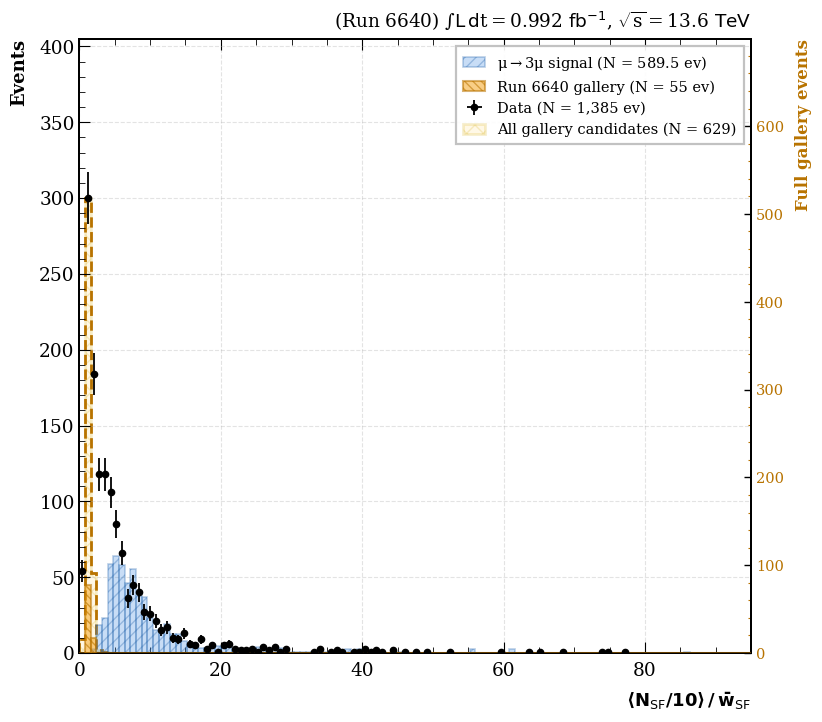

In [ ]:
# Options:
#   - "hits_plane_sf" / w_bar_sf   -> <N_hits^SF / 10> / w_bar_SF (as shown in attached plot)
#   - "emip_sf"                    -> epsilon_mip^SF
#   - "rhomip_sf"                  -> rho_mip^SF
#   - "qdc_plane_sf"               -> QDC^SF / 10
#   - "emip_ds"                    -> epsilon_mip^DS
#   - "rhomip_ds"                  -> rho_mip^DS
val_data = df_data["emip_sf"].to_numpy() / w_bar_sf
val_mc = df_mc["emip_sf"].to_numpy() / w_bar_sf
mc_weights = df_mc["weight"].to_numpy() * SCALE_MC_TO_FULL
val_gal_6640 = df_gal_6640["emip_sf"].to_numpy() / w_bar_sf
val_gal_all = df_gal_all["emip_sf"].to_numpy() / w_bar_sf

x_label = (
    r"$\mathbf{\langle N_{\mathrm{SF}} / 10 \rangle \,/\, \bar{w}_{\mathrm{SF}}}$"
)
x_max = 95.0
bin_width = 0.80

bins = np.arange(0.0, x_max + bin_width, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])


import matplotlib.ticker as ticker
fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax_twin = ax.twinx()

if len(val_gal_all) > 0:
  counts_gal_all, _ = np.histogram(val_gal_all, bins=bins)
  ax_twin.hist(
      val_gal_all,
      bins=bins,
      histtype="stepfilled",
      facecolor="#FFE082",
      edgecolor="#D4AC0D",
      linestyle="-",
      linewidth=2.0,
      alpha=0.20,
      hatch="xx",
      zorder=5,
      label=rf"All gallery candidates (N = {len(val_gal_all):,})",
  )
  
  ax_twin.hist(
      val_gal_all,
      bins=bins,
      histtype="step",
      color="#B87300",
      linestyle="--",
      linewidth=2.0,
      zorder=6,
  )
  ax_twin.set_ylabel(
      "Full gallery events",
      fontweight="bold",
      color="#B87300",
      fontsize=12,
      labelpad=8,
  )
  ax_twin.tick_params(
      axis="y", labelcolor="#B87300", labelsize=10.5, length=5, width=1.0
  )
  ax_twin.set_ylim(0, counts_gal_all.max() * 1.35)
  ax_twin.yaxis.set_minor_locator(ticker.AutoMinorLocator())
  ax_twin.tick_params(
      axis="y", which="minor", length=2.5, width=0.8, color="#B87300"
  )

# ----------------- Left Axis: MC Signal (Hatched Blue) -----------------
n_mc_expected = np.sum(mc_weights)
ax.hist(
    val_mc,
    bins=bins,
    weights=mc_weights,
    facecolor="#4A90E2",
    alpha=0.30,  # Slightly lower alpha so underlying shapes show through
    hatch="///",
    edgecolor="#1C5FA8",
    linewidth=1.2,
    zorder=2,
    label=rf"$\mu \to 3\mu$ signal (N = {n_mc_expected:.1f} ev)",
)

# ----------------- Left Axis: Run 6640 Gallery (Hatched Gold) ----------
if len(val_gal_6640) > 0:
  ax.hist(
      val_gal_6640,
      bins=bins,
      facecolor="#F5A623",
      alpha=0.55,
      hatch=r"\\\\",
      edgecolor="#B87300",
      linewidth=1.5,
      zorder=3,
      label=rf"Run 6640 gallery (N = {len(val_gal_6640)} ev)",
  )

# ----------------- Left Axis: Collision Data --------------------------
counts_data, _ = np.histogram(val_data, bins=bins)
err_data = np.sqrt(counts_data)
mask_nonzero = counts_data > 0

ax.errorbar(
    bin_centers[mask_nonzero],
    counts_data[mask_nonzero],
    yerr=err_data[mask_nonzero],
    xerr=bin_width / 2.0,
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=1.3,
    capsize=0,
    markersize=4.5,
    zorder=10,
    label=rf"Data (N = {len(val_data):,} ev)",
)

ax.set_xlim(0.0, x_max)
y_max = max(counts_data.max() if len(counts_data) > 0 else 0, 50)
ax.set_ylim(bottom=0, top=y_max * 1.35)

ax.set_xlabel(x_label, fontweight="bold", fontsize=13, labelpad=8)
ax.set_ylabel("Events", fontweight="bold", fontsize=13, labelpad=8)

# Layer twin axis properly so stepped outline remains crisp
ax.set_zorder(ax_twin.get_zorder() + 1)
ax.patch.set_visible(False)

# Grid & Ticks
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", linestyle="--", alpha=0.35, zorder=0)

# Legend
handles_left, labels_left = ax.get_legend_handles_labels()
handles_right, labels_right = ax_twin.get_legend_handles_labels()

ax.legend(
    handles=handles_left + handles_right,
    labels=labels_left + labels_right,
    loc="upper right",
    frameon=True,
    framealpha=0.92,
    edgecolor="#BDBDBD",
    facecolor="white",
    fontsize=10.5,
)

# Publication Header
add_label(
    loc="top-left",
    supp_loc="top-right",
    mainText="", extraText="",
    suppText="(Run 6640)",
    lumi=LUMI_FULL_6640,
    com=13.6,
    style="formal",
    ax=ax,
)

plt.tight_layout()
plt.show()
plt.close(fig)